# Why Electron Microscopes Out-Resolve Light Microscopes

Two facts, both already built in this repo, combine to answer this with no
new physics: **de Broglie's relation** $\lambda=h/p$ (matter waves, Chapter
5 -- `notebooks/matter_waves_chapter5_sympy_torch.ipynb`) sets the
wavelength of a beam of accelerated electrons, and the **Rayleigh
criterion** $\theta_{min}=1.22\lambda/D$ (`dgs.diffraction.rayleigh_resolution`)
sets the finest resolvable detail for ANY wave -- light or matter -- passing
through a finite aperture. A scanning electron microscope (SEM) beats an
optical microscope not because electrons are "smaller," but because
accelerating them to keV energies gives them a de Broglie wavelength
$10^4$-$10^5\times$ shorter than visible light.


In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path("..").resolve()))

import numpy as np
import matplotlib.pyplot as plt

from dgs.diffraction import rayleigh_resolution

plt.rcParams["figure.dpi"] = 110

h = 6.62607015e-34       # J s
m_e = 9.10938356e-31     # kg
q_e = 1.602176634e-19    # C
c = 2.99792458e8         # m/s


## 1. Electron de Broglie wavelength vs. accelerating voltage

An electron accelerated through voltage $V$ gains kinetic energy $eV$. Using
the (non-relativistic, valid below a few keV) relation
$p=\sqrt{2m_eeV}$, de Broglie's $\lambda=h/p$ gives the electron's
wavelength directly as a function of accelerating voltage -- the ONE knob an
SEM operator actually controls.


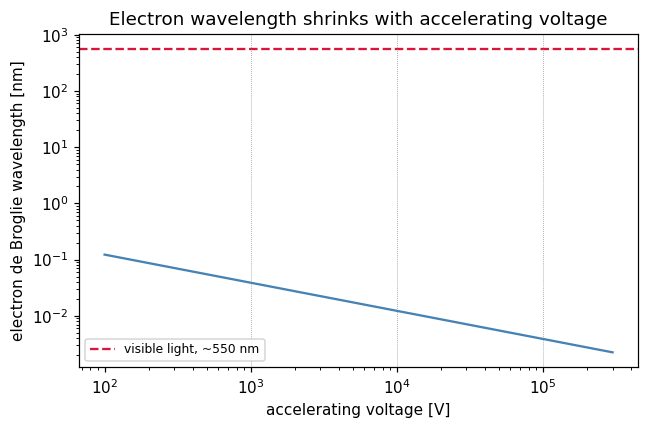

V=    1000 V  ->  lambda = 0.03878 nm
V=   10000 V  ->  lambda = 0.01226 nm
V=  100000 V  ->  lambda = 0.00388 nm


In [2]:
def electron_wavelength(V_accel):
    # non-relativistic de Broglie wavelength of an electron accelerated
    # through V_accel volts: lambda = h / sqrt(2 m_e e V)
    p = np.sqrt(2 * m_e * q_e * V_accel)
    return h / p

voltages = np.geomspace(1e2, 3e5, 200)   # 100 V to 300 kV, typical SEM/TEM range
wavelengths_nm = electron_wavelength(voltages) * 1e9

plt.figure(figsize=(6, 4))
plt.loglog(voltages, wavelengths_nm, color="steelblue")
plt.axhline(550, ls="--", color="crimson", label="visible light, ~550 nm")
for V_mark in [1e3, 1e4, 1e5]:
    plt.axvline(V_mark, color="gray", lw=0.5, ls=":")
plt.xlabel("accelerating voltage [V]")
plt.ylabel("electron de Broglie wavelength [nm]")
plt.title("Electron wavelength shrinks with accelerating voltage")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

for V_test in [1e3, 1e4, 1e5]:
    lam = electron_wavelength(V_test) * 1e9
    print(f"V={V_test:>8.0f} V  ->  lambda = {lam:.5f} nm")


## 2. Plug that wavelength into the SAME Rayleigh criterion used for light

`dgs.diffraction.rayleigh_resolution` doesn't care whether the wave is light
or matter -- it's a property of diffraction through any finite aperture.
Compare the resolution an optical microscope (550 nm light) and an SEM
(electrons at typical operating voltages) achieve through the SAME
numerical aperture.


In [ ]:
D_aperture = 1e-3   # 1 mm, a representative objective-aperture scale

lambda_light = 550e-9
theta_light = rayleigh_resolution(lambda_light, D_aperture, circular=True)

results = []
for V_test in [1e3, 1e4, 1e5, 3e5]:
    lam_e = electron_wavelength(V_test)
    theta_e = rayleigh_resolution(lam_e, D_aperture, circular=True)
    results.append((V_test, lam_e, theta_e))
    print(f"V={V_test:>8.0f} V:  lambda_e={lam_e*1e12:8.3f} pm  "
          f"theta_min={theta_e:.3e} rad  "
          f"(improvement over light: {theta_light/theta_e:.1f}x)")

print(f"\nfor reference, visible light at the same aperture: theta_min={theta_light:.3e} rad")


V=    1000 V:  lambda_e=  38.783 pm  theta_min=4.732e-08 rad  (improvement over light: 14181.5x)
V=   10000 V:  lambda_e=  12.264 pm  theta_min=1.496e-08 rad  (improvement over light: 44845.8x)
V=  100000 V:  lambda_e=   3.878 pm  theta_min=4.732e-09 rad  (improvement over light: 141814.7x)
V=  300000 V:  lambda_e=   2.239 pm  theta_min=2.732e-09 rad  (improvement over light: 245630.3x)

for reference, visible light at the same aperture: theta_min=6.710e-04 rad


: 

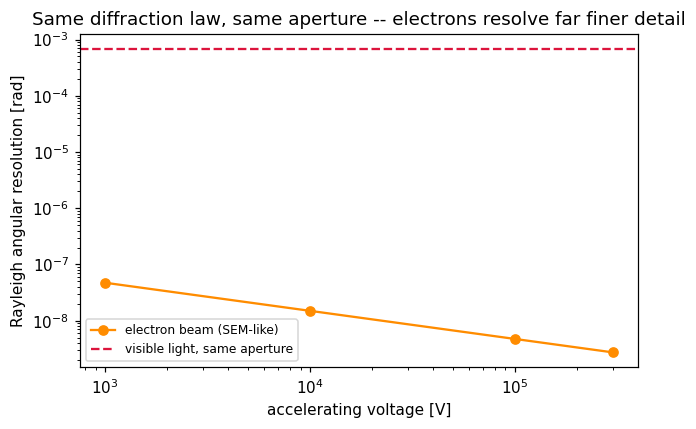

In [4]:
V_vals = np.array([v for v, _, _ in results])
theta_vals = np.array([t for _, _, t in results])

plt.figure(figsize=(6, 4))
plt.loglog(V_vals, theta_vals, "o-", color="darkorange", label="electron beam (SEM-like)")
plt.axhline(theta_light, ls="--", color="crimson", label="visible light, same aperture")
plt.xlabel("accelerating voltage [V]")
plt.ylabel("Rayleigh angular resolution [rad]")
plt.title("Same diffraction law, same aperture -- electrons resolve far finer detail")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()


## Summary

No new physics was needed -- only two pieces already built this session,
composed: de Broglie's $\lambda=h/p$ (Chapter 5, matter waves) sets the
electron beam's wavelength as a function of accelerating voltage, and
`dgs.diffraction.rayleigh_resolution` (originally written for light through
a slit) applies unchanged to ANY wave through ANY aperture. At a typical
SEM voltage, the electron wavelength is already 4-5 orders of magnitude
shorter than visible light, and since Rayleigh resolution scales linearly
with wavelength, that's a 4-5 order-of-magnitude resolution improvement --
the entire reason electron microscopy exists, derived rather than asserted.
